# Fase 1: Configuración del Entorno y Carga de Librerías
En esta fase preparamos nuestro espacio de trabajo importando las librerías necesarias para análisis tabular, geoespacial y visualización.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Configuraciones de visualización
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Fase 2: Análisis Espacial de las Reservas Objetivo (CONABIO)
Cargamos el archivo GeoJSON generado previamente que contiene exclusivamente los polígonos de la Reserva de la Biósfera El Triunfo y La Sepultura. Inspeccionamos su estructura y sistemas de coordenadas (CRS).

In [2]:
# Cargar el archivo de las reservas
reservas_path = 'data/reservas_objetivo/reservas_chiapas.geojson'
reservas_gdf = gpd.read_file(reservas_path)

# Mostrar la estructura general
print(f"Sistema de Coordenadas (CRS): {reservas_gdf.crs}")
print(f"Número de registros: {len(reservas_gdf)}")
reservas_gdf.head()

Sistema de Coordenadas (CRS): EPSG:4326
Número de registros: 2


,ID_ANP,NOMBRE,CAT_DECRET,CAT_MANEJO,ESTADOS,MUNICIPIOS,REGION,SUPERFICIE,S_TERRES,S_MARINA,PRIM_DEC,ULT_DOF,PCM1,SINAP,COV_ID,etiqueta,numpoligon,cita,COV_,geometry
0,8.1.03.096,El Triunfo,RB,RB,Chiapas,"Villa Corzo, Pijijiapan, La Concordia, Ãngel ...","Frontera Sur, Istmo y PacÃ­fico Sur",119177.2900,119177.2900,0.0,1990-03-13,1990-05-15,2000-09-15,SINAP,8103096,El Triunfo,1,CONANP. 2017. Ãreas Naturales Protegidas Fede...,130,"POLYGON ((-92.73311 15.75459, -92.73311 15.752..."
1,8.1.06.119,La Sepultura,RB,RB,Chiapas,"Cintalapa, Jiquipilas, Villa Flores, Villa Cor...","Frontera Sur, Istmo y PacÃ­fico Sur",167309.8625,167309.8625,0.0,1995-06-06,1995-06-06,2000-09-15,SINAP,8106119,La Sepultura,1,CONANP. 2017. Ãreas Naturales Protegidas Fede...,134,"POLYGON ((-93.94152 16.46115, -93.90403 16.457..."


Ahora graficamos estas reservas en un mapa interactivo utilizando Folium para tener contexto geográfico.

In [3]:
# Calcular el centroide promedio para centrar el mapa (se usa to_crs para asegurar un calculo preciso aunque folium usa WGS84)
centroides = reservas_gdf.copy().to_crs('+proj=cea').centroid.to_crs(reservas_gdf.crs)
center_lat = centroides.y.mean()
center_lon = centroides.x.mean()


# Convertir fechas a texto para que Folium pueda serializar el JSON
for col in reservas_gdf.select_dtypes(include=['datetime64', 'datetimetz']).columns:
    reservas_gdf[col] = reservas_gdf[col].astype(str)

# Crear mapa base
m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles='CartoDB positron')

# Agregar los polígonos al mapa
folium.GeoJson(
    reservas_gdf,
    name="Reservas Objetivo",
    style_function=lambda feature: {
        'fillColor': '#228B22',
        'color': '#006400',
        'weight': 2,
        'fillOpacity': 0.5,
    },
    tooltip=folium.GeoJsonTooltip(fields=['NOMBRE'], aliases=['Reserva:'])
).add_to(m)

# Mostrar mapa
m

## Fase 3: Análisis y Limpieza de Incendios Históricos (CONAFOR)
En esta fase procesaremos la base de datos tabular de la CONAFOR. Como el archivo contiene más de 71,000 registros a nivel nacional/estatal, lo transformaremos en un formato espacial y realizaremos un *Spatial Join* para aislar **únicamente** los incendios que sucedieron dentro de nuestras dos reservas.

In [4]:
# Cargar el dataset tabular de CONAFOR
# Usamos encoding latin1 porque es un archivo gubernamental y puede contener acentos
csv_path = 'data/estadisticasincendiosforestales2015-2024.csv'
incendios_df = pd.read_csv(csv_path, encoding='latin1', low_memory=False)

print(f"Total de registros originales: {len(incendios_df)}")

# Limpieza básica: Eliminar filas que no tengan coordenadas válidas
incendios_df = incendios_df.dropna(subset=['latitud', 'longitud'])

# Crear geometria a partir de latitud y longitud
geometry = [Point(xy) for xy in zip(incendios_df['longitud'], incendios_df['latitud'])]

# Convertir a GeoDataFrame asignando el sistema de coordenadas estándar (WGS84)
incendios_gdf = gpd.GeoDataFrame(incendios_df, geometry=geometry, crs="EPSG:4326")

print(f"Total de registros con coordenadas válidas: {len(incendios_gdf)}")

Total de registros originales: 71089
Total de registros con coordenadas válidas: 71089


Ahora aplicamos la magia espacial: El **Spatial Join** filtra los incendios, cruzando los puntos geográficos de CONAFOR con los polígonos de nuestras reservas.

In [5]:
# Realizar el Spatial Join (Intersección Espacial)
# Retendrá solo los puntos (incendios) que caen 'dentro' (within) de los polígonos (reservas)
incendios_reservas = gpd.sjoin(incendios_gdf, reservas_gdf, how="inner", predicate="within")

print(f"¡Filtrado exitoso! Incendios ocurridos DENTRO de las reservas: {len(incendios_reservas)}")

# Ver columnas relevantes
columnas_interes = ['Clave_del_incendio', 'Fecha_Inicio', 'Total_hectareas', 'NOMBRE', 'Causa']
display(incendios_reservas[columnas_interes].head())

¡Filtrado exitoso! Incendios ocurridos DENTRO de las reservas: 596


,Clave_del_incendio,Fecha_Inicio,Total_hectareas,NOMBRE,Causa
239,15-07-0009,2015-01-14,15.0,La Sepultura,Actividades agropecuarias
244,15-07-0014,2015-01-28,5.0,La Sepultura,Intencional
249,15-07-0019,2015-01-31,1.0,El Triunfo,Intencional
253,15-07-0023,2015-02-08,6.5,La Sepultura,Fumadores
260,15-07-0030,2015-02-18,15.0,La Sepultura,Actividades agropecuarias


Añadiremos estos puntos de incendios al mapa para visualizar dónde ocurrieron históricamente dentro de las reservas.

In [6]:
# Añadir los incendios filtrados al mapa interactivo que creamos antes
# Creamos un FeatureGroup para poder activarlo/desactivarlo
fg_incendios = folium.FeatureGroup(name="Incendios Históricos (CONAFOR)")

for idx, row in incendios_reservas.iterrows():
    # Extraemos lat y lon de la geometria validada
    lat, lon = row.geometry.y, row.geometry.x
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color='red',
        fill=True,
        fill_color='darkred',
        fill_opacity=0.7,
        tooltip=f"Incendio: {row['Clave_del_incendio']} <br> Área: {row['Total_hectareas']} ha <br> Causa: {row['Causa']}"
    ).add_to(fg_incendios)

fg_incendios.add_to(m)
folium.LayerControl().add_to(m)

# Mostrar el mapa actualizado
m

Finalmente, analizaremos la **estacionalidad**. ¿En qué meses ocurren la mayoría de estos incendios? Esto es crítico para nuestros modelos predictivos.

/tmp/ipykernel_56595/1647699756.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=incendios_reservas, x='Mes', palette='YlOrRd')


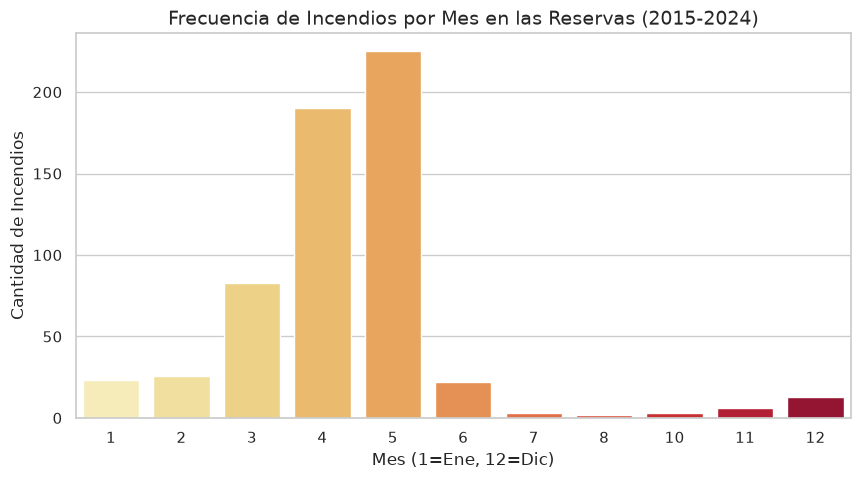

In [7]:
# Convertir 'Fecha_Inicio' a tipo datetime real
incendios_reservas['Fecha_Inicio'] = pd.to_datetime(incendios_reservas['Fecha_Inicio'], errors='coerce')

# Extraer el mes
incendios_reservas['Mes'] = incendios_reservas['Fecha_Inicio'].dt.month

# Graficar histograma
plt.figure(figsize=(10, 5))
sns.countplot(data=incendios_reservas, x='Mes', palette='YlOrRd')
plt.title('Frecuencia de Incendios por Mes en las Reservas (2015-2024)', fontsize=14)
plt.xlabel('Mes (1=Ene, 12=Dic)', fontsize=12)
plt.ylabel('Cantidad de Incendios', fontsize=12)
plt.show()

## Fase 4: Análisis y Limpieza de Datos Satelitales (NASA FIRMS)
CONAFOR nos da los reportes oficiales, pero los satélites de la NASA (como VIIRS) detectan *Anomalías Térmicas* de forma automática. Aquí cargaremos todos los archivos CSV de la NASA que descargaste, los uniremos, filtraremos la 'basura' (detecciones de baja confianza) y haremos otro Spatial Join para quedarnos solo con el calor detectado dentro de las reservas.

In [8]:
import glob

# Encontrar todos los archivos CSV de FIRMS en subcarpetas
firms_files = glob.glob('data/DL_FIRE_*/*.csv')
print("Archivos FIRMS encontrados:", firms_files)

# Leer y concatenar todos los archivos en un solo DataFrame
dfs = []
for file in firms_files:
    dfs.append(pd.read_csv(file, low_memory=False))

firms_df = pd.concat(dfs, ignore_index=True)
print(f"Total de registros térmicos iniciales: {len(firms_df)}")

# Filtrar detecciones de baja confianza
if 'confidence' in firms_df.columns:
    # Chequear si es texto ('l', 'n', 'h') o numérico
    if firms_df['confidence'].astype(str).str.isalpha().any():
        firms_df = firms_df[firms_df['confidence'].astype(str).str.lower() != 'l']
    else:
        firms_df = firms_df[pd.to_numeric(firms_df['confidence'], errors='coerce') >= 50]

print(f"Total tras limpiar baja confianza: {len(firms_df)}")

Archivos FIRMS encontrados: ['data/DL_FIRE_SV-C2_766069/fire_archive_SV-C2_766069.csv', 'data/DL_FIRE_SV-C2_766069/fire_nrt_SV-C2_766069.csv', 'data/DL_FIRE_J2V-C2_766068/fire_nrt_J2V-C2_766068.csv', 'data/DL_FIRE_J1V-C2_766067/fire_archive_J1V-C2_766067.csv', 'data/DL_FIRE_J1V-C2_766067/fire_nrt_J1V-C2_766067.csv']
Total de registros térmicos iniciales: 9996
Total tras limpiar baja confianza: 9526


Ahora convertimos estas coordenadas térmicas en una capa espacial y aplicamos el mismo **Spatial Join** contra los polígonos de nuestras reservas.

In [9]:
# Crear geometrías y GeoDataFrame
geom_firms = [Point(xy) for xy in zip(firms_df['longitude'], firms_df['latitude'])]
firms_gdf = gpd.GeoDataFrame(firms_df, geometry=geom_firms, crs="EPSG:4326")

# Realizar el Spatial Join
firms_reservas = gpd.sjoin(firms_gdf, reservas_gdf, how="inner", predicate="within")

print(f"Puntos de calor (FIRMS) DENTRO de las reservas: {len(firms_reservas)}")

# Ver muestra
columnas_firms = ['acq_date', 'acq_time', 'satellite', 'confidence', 'frp', 'NOMBRE']
display(firms_reservas[columnas_firms].head())

Puntos de calor (FIRMS) DENTRO de las reservas: 698


,acq_date,acq_time,satellite,confidence,frp,NOMBRE
150,2016-04-06,731,SNPP,n,4.02,El Triunfo
151,2016-04-06,731,SNPP,n,3.92,El Triunfo
158,2016-04-07,2001,SNPP,n,8.72,El Triunfo
295,2016-04-20,1917,SNPP,n,11.56,El Triunfo
305,2016-04-26,1905,SNPP,n,2.91,El Triunfo


Vamos a agregar estos puntos de calor satelitales al mapa para compararlos con los de CONAFOR. Los mostraremos en color **naranja**.

In [10]:
# Para evitar conflictos gráficos con el mapa anterior, crearemos uno nuevo combinando ambas capas
m_satelite = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles='CartoDB dark_matter')

# Añadir los polígonos de las reservas
folium.GeoJson(
    reservas_gdf,
    name="Reservas Objetivo",
    style_function=lambda feature: {
        'fillColor': '#228B22',
        'color': '#00FF00',
        'weight': 2,
        'fillOpacity': 0.2,
    }
).add_to(m_satelite)

# Añadir capa FIRMS (Naranja)
fg_firms = folium.FeatureGroup(name="NASA FIRMS (Satélite)")
for idx, row in firms_reservas.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2,
        color='orange',
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Fecha: {row['acq_date']} <br> Satélite: {row['satellite']}"
    ).add_to(fg_firms)

# Añadir capa CONAFOR (Rojo)
fg_incendios_2 = folium.FeatureGroup(name="CONAFOR (Oficial)")
for idx, row in incendios_reservas.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Incendio CONAFOR: {row.get('Clave_del_incendio', 'N/A')}"
    ).add_to(fg_incendios_2)

fg_firms.add_to(m_satelite)
fg_incendios_2.add_to(m_satelite)
folium.LayerControl().add_to(m_satelite)

# Renderizar el nuevo mapa
m_satelite

## Fase 5: Integración de Variables Meteorológicas (Open-Meteo)
El fuego no aparece de la nada, es consecuencia de condiciones climáticas extremas. Para entender esto, vamos a descargar de golpe todo el historial climático de los últimos 10 años para el centro geográfico de las reservas usando la API de **Open-Meteo Archive**. Luego, veremos qué variables climáticas (temperatura alta, sequía) coinciden más fuerte con los días en que **sí hubo** incendios.

In [11]:
import requests
from datetime import datetime

# Usaremos el centroide de 'El Triunfo' como punto de referencia climático representativo
reserva_obj = reservas_gdf.iloc[0]
lat, lon = reserva_obj.geometry.centroid.y, reserva_obj.geometry.centroid.x

print(f"Obteniendo historial climático para lat: {lat:.2f}, lon: {lon:.2f} (2015-2024)...")

# Llamar a la API de archivo histórico de Open-Meteo
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2015-01-01",
    "end_date": "2024-12-31",
    "daily": ["temperature_2m_max", "relative_humidity_2m_mean", "wind_speed_10m_max", "precipitation_sum"],
    "timezone": "America/Mexico_City"
}

response = requests.get(url, params=params)
clima_data = response.json()

# Crear un DataFrame con el historial diario
clima_df = pd.DataFrame({
    'fecha': pd.to_datetime(clima_data['daily']['time']),
    'temp_max': clima_data['daily']['temperature_2m_max'],
    'humedad_media': clima_data['daily']['relative_humidity_2m_mean'],
    'viento_max': clima_data['daily']['wind_speed_10m_max'],
    'precipitacion': clima_data['daily']['precipitation_sum']
})

# Llenar valores nulos (interpolación básica)
clima_df = clima_df.interpolate(method='linear')

print(f"Historial descargado con éxito. {len(clima_df)} días de clima almacenados.")
display(clima_df.head())

Obteniendo historial climático para lat: 15.66, lon: -92.85 (2015-2024)...
Historial descargado con éxito. 3653 días de clima almacenados.


,fecha,temp_max,humedad_media,viento_max,precipitacion
0,2015-01-01,21.9,63,9.6,0.2
1,2015-01-02,24.7,60,6.9,0.0
2,2015-01-03,23.6,61,4.8,0.0
3,2015-01-04,23.8,60,9.9,0.0
4,2015-01-05,23.2,61,20.2,0.0


Ahora cruzamos este historial climático con los días en que CONAFOR reportó incendios para crear nuestra variable objetivo `es_incendio` (1 si hubo fuego ese día, 0 si fue un día normal). Finalmente creamos una Matriz de Correlación para comprobar matemáticamente la influencia del clima.

De 3653 días evaluados, hubo incendios en 444 días distintos.


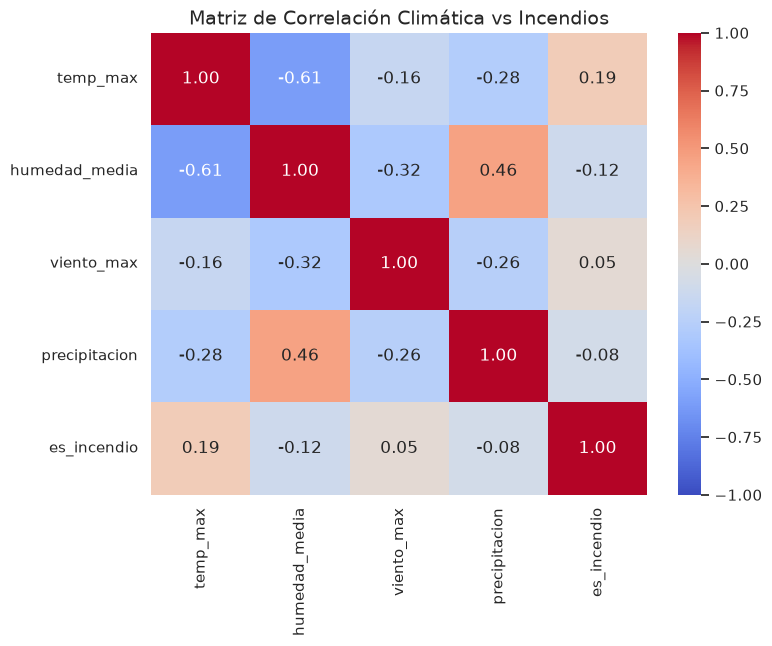

Condiciones promedio en días NORMALES vs días con INCENDIO:


,temp_max,humedad_media,viento_max
es_incendio,,,
0,20.162169,80.912745,10.379059
1,21.360811,77.459459,11.054955


In [12]:
# Obtener solo la fecha (sin horas) de los incendios de CONAFOR
fechas_incendios = incendios_reservas['Fecha_Inicio'].dt.floor('D').unique()

# Crear columna objetivo (Feature Engineering base)
clima_df['es_incendio'] = clima_df['fecha'].isin(fechas_incendios).astype(int)

dias_con_fuego = clima_df['es_incendio'].sum()
print(f"De {len(clima_df)} días evaluados, hubo incendios en {dias_con_fuego} días distintos.")

# Matriz de Correlación
columnas_corr = ['temp_max', 'humedad_media', 'viento_max', 'precipitacion', 'es_incendio']
corr_matrix = clima_df[columnas_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación Climática vs Incendios', fontsize=14)
plt.show()

# Ver comparación directa de medias
print("Condiciones promedio en días NORMALES vs días con INCENDIO:")
display(clima_df.groupby('es_incendio')[['temp_max', 'humedad_media', 'viento_max']].mean())

## Fase 6: Simulaciones y Pruebas Conceptuales de Machine Learning
Antes de llevar el código al Backend definitivo, vamos a validar nuestra hipótesis: ¿Realmente un modelo *no supervisado* puede separar los climas peligrosos de los normales sin que nosotros le digamos explícitamente cuáles días tuvieron fuego? Para esto usaremos **K-Means** e **Isolation Forest**.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

# Preparar las variables climáticas
features = ['temp_max', 'humedad_media', 'viento_max', 'precipitacion']
X = clima_df[features].copy()

# Es vital escalar (normalizar) los datos en algoritmos de distancia
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados correctamente. Listos para ML.")

Datos escalados correctamente. Listos para ML.


### 6.1 Prueba con K-Means (Contexto Estacional)
Le pediremos a K-Means que agrupe los más de 3,600 días en 4 clústeres distintos. Esperamos que un clúster agrupe los días muy fríos/lluviosos y otro los días muy secos/calientes.

In [14]:
# Entrenar K-Means con 4 clusters (Bajo, Medio, Alto, Crítico)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
clima_df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

import plotly.express as px

# Visualizar la separación en 3D (Temp, Humedad, Viento) para poder explorarlo en el navegador
fig = px.scatter_3d(
    clima_df, 
    x='temp_max', 
    y='humedad_media', 
    z='viento_max',
    color='cluster_kmeans',
    title='Agrupamiento de Días por K-Means (Temp vs Humedad vs Viento)',
    opacity=0.6,
    color_continuous_scale='Viridis',
    labels={'temp_max': 'Temp Max (°C)', 'humedad_media': 'Humedad (%)', 'viento_max': 'Viento (km/h)'}
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

# Veamos cuántos incendios reales cayeron en cada clúster
print("Incendios reales por Clúster generado:")
display(clima_df.groupby('cluster_kmeans')['es_incendio'].sum().sort_values(ascending=False))

Incendios reales por Clúster generado:


cluster_kmeans
2    197
0    189
3     48
1     10
Name: es_incendio, dtype: int64

### 6.2 Prueba con Isolation Forest (Anomalías Críticas)
El Isolation Forest no agrupa, aísla. Buscará las anomalías estadísticas más agresivas. Le diremos que asuma que el 5% de nuestros datos (los días más extremos en 10 años) son anomalías.

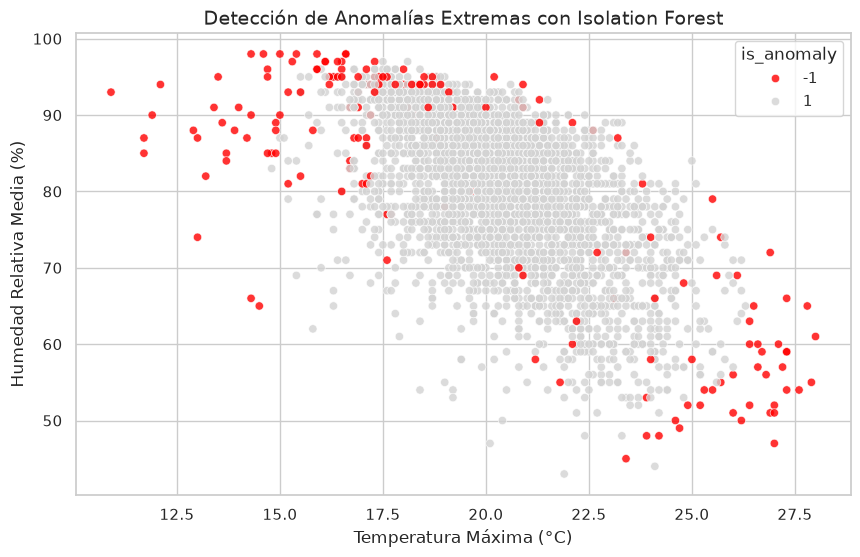

De los incendios ocurridos, 15 sucedieron en días estadísticamente anómalos/extremos.


In [15]:
# Entrenar Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
# Devuelve 1 para normal, -1 para anomalía
clima_df['is_anomaly'] = iso_forest.fit_predict(X_scaled)
# Extraer el 'Score' continuo (menor puntaje = más anómalo)
clima_df['anomaly_score'] = iso_forest.decision_function(X_scaled)

# Visualizar las anomalías detectadas
plt.figure(figsize=(10, 6))
# Colorear en rojo las anomalías (-1), en gris los días normales (1)
colores = {1: 'lightgrey', -1: 'red'}
sns.scatterplot(data=clima_df, x='temp_max', y='humedad_media', 
                hue='is_anomaly', palette=colores, alpha=0.8)
plt.title('Detección de Anomalías Extremas con Isolation Forest', fontsize=14)
plt.xlabel('Temperatura Máxima (°C)')
plt.ylabel('Humedad Relativa Media (%)')
plt.show()

# Comprobar si las anomalías detectadas coinciden con los incendios reales
anomalias_con_fuego = clima_df[(clima_df['is_anomaly'] == -1) & (clima_df['es_incendio'] == 1)]
print(f"De los incendios ocurridos, {len(anomalias_con_fuego)} sucedieron en días estadísticamente anómalos/extremos.")

## Fase 7: Exportación de Dataset Limpio
Nuestras pruebas han sido un éxito. Ahora guardaremos este historial estructurado, limpio y enriquecido con nuestras variables ML. Este archivo CSV será la base de datos de entrenamiento definitivo que importará nuestro Backend (FastAPI).

In [16]:
import os

out_dir = 'data'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'dataset_ML_preparado.csv')

# Guardar el dataset
clima_df.to_csv(out_path, index=False)

print(f"¡EDA Completado exitosamente! Dataset listo exportado en: {out_path}")
print("Columnas finales:", clima_df.columns.tolist())

¡EDA Completado exitosamente! Dataset listo exportado en: data/dataset_ML_preparado.csv
Columnas finales: ['fecha', 'temp_max', 'humedad_media', 'viento_max', 'precipitacion', 'es_incendio', 'cluster_kmeans', 'is_anomaly', 'anomaly_score']
